# Breast Cancer (Wisconsin) — Quick EDA Notebook


In [ ]:
import numpy as np

from sklearn.datasets import load_breast_cancer

## Load data


In [ ]:
#https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset
data = load_breast_cancer(as_frame=True)
X = data.data    # 30 measurements of cell nuclei
y = data.target  # 1-Benign, 0-Malignant
print(X.shape)
print(y.unique(), data.target_names)
y.value_counts()

(569, 30)
[0 1] ['malignant' 'benign']


target
1    357
0    212
Name: count, dtype: int64

# Cleaning

The data is curated so this should be a sanity check only.


In [ ]:
# 1) Missing values
n_missing = X.isna().sum().sum()
print("Total missing values:", int(n_missing))

# 2) Duplicates
n_dup = X.duplicated().sum()
print("Duplicate rows:", int(n_dup))

# 3) Constant / near-constant columns
nunique = X.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
print("Constant columns:", const_cols)

# Optional: near-constant (>= 99.5% same value)
near_const = []
for c in X.columns:
    top_frac = X[c].value_counts(normalize=True).iloc[0]
    if top_frac >= 0.995:
        near_const.append((c, float(top_frac)))
print("Near-constant columns:", near_const[:10])

# 4) Basic numeric sanity
non_numeric = [c for c in X.columns if not np.issubdtype(X[c].dtype, np.number)]
print("Non-numeric columns:", non_numeric)

# 5) Distribution sanity (summary statistics)
summary = X.describe().T
# Flag features with extreme scale ratios (potential numerical dominance)
summary["max/min"] = summary["max"] / summary["min"].replace(0, np.nan)

summary.sort_values("max/min", ascending=False).head(10)

Total missing values: 0
Duplicate rows: 0
Constant columns: []
Near-constant columns: []
Non-numeric columns: []


,count,mean,std,min,25%,50%,75%,max,max/min
area error,569.0,40.337079,45.491006,6.802000,17.850000,24.530000,45.190000,542.20000,79.711849
compactness error,569.0,0.025478,0.017908,0.002252,0.013080,0.020450,0.032450,0.13540,60.124334
worst compactness,569.0,0.254265,0.157336,0.027290,0.147200,0.211900,0.339100,1.05800,38.768780
fractal dimension error,569.0,0.003795,0.002646,0.000895,0.002248,0.003187,0.004558,0.02984,33.348234
perimeter error,569.0,2.866059,2.021855,0.757000,1.606000,2.287000,3.357000,21.98000,29.035667
radius error,569.0,0.405172,0.277313,0.111500,0.232400,0.324200,0.478900,2.87300,25.766816
worst area,569.0,880.583128,569.356993,185.200000,515.300000,686.500000,1084.000000,4254.00000,22.969762
smoothness error,569.0,0.007041,0.003003,0.001713,0.005169,0.006380,0.008146,0.03113,18.172796
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,17.822497
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,17.428571


## Distributions


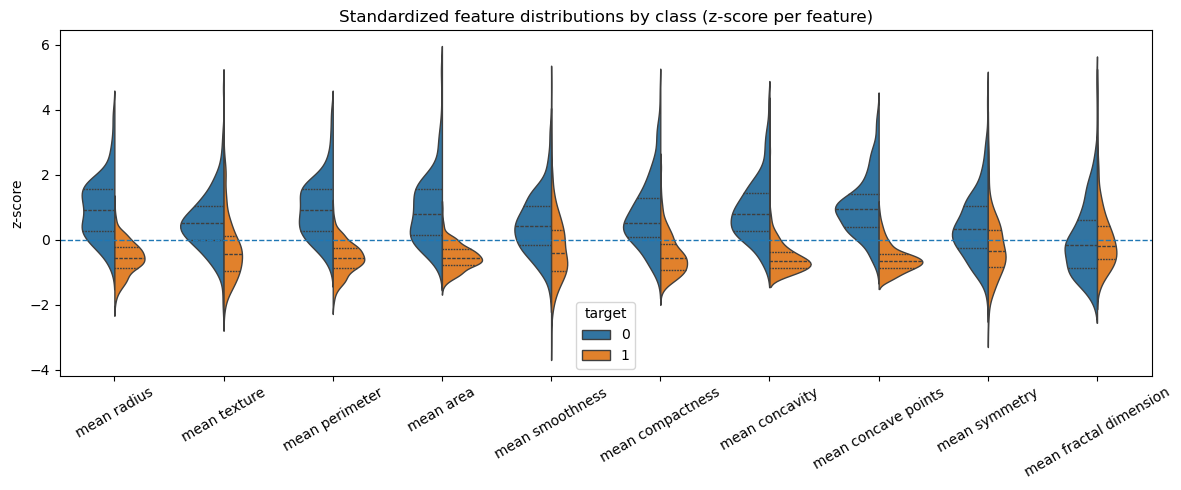

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import StandardScaler

cols = X.columns[:10]
X_subset = X[cols]

# Standardize per feature (z-score)
Xz = pd.DataFrame(StandardScaler().fit_transform(X_subset), columns=cols)

df_long = Xz.assign(target=y).melt(id_vars="target", var_name="feature", value_name="z")

plt.figure(figsize=(12, 5))
sns.violinplot(data=df_long, x="feature", y="z", hue="target", split=True, inner="quartile", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Standardized feature distributions by class (z-score per feature)")
plt.xlabel("")
plt.ylabel("z-score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


The classification is going to be easy: mean area, concavity, concave points clearly seperate the classes.


# Correlations


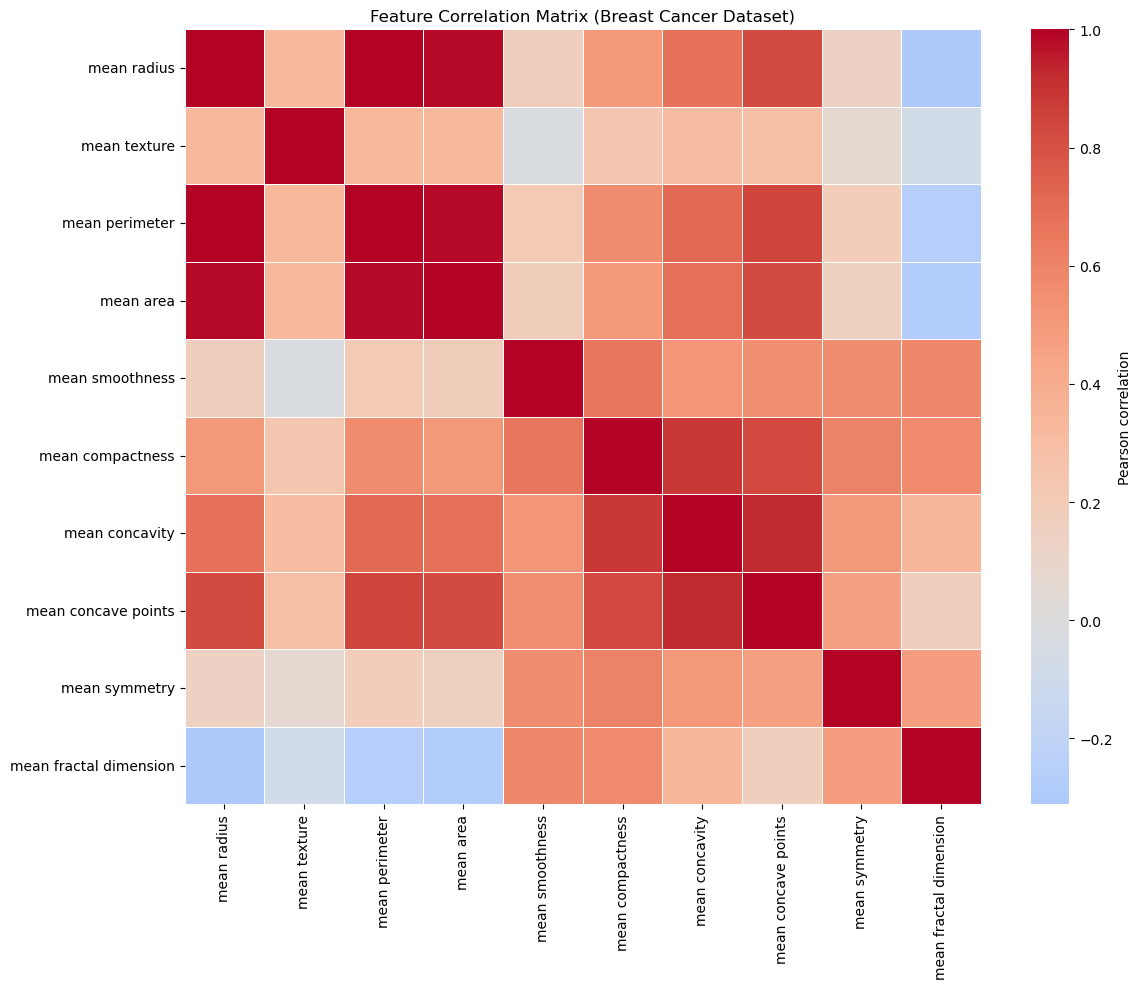

In [ ]:
# Correlation matrix of numeric features
import matplotlib.pyplot as plt
import seaborn as sns

corr = X_subset.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5, cbar_kws={"label": "Pearson correlation"})
plt.title("Feature Correlation Matrix (Breast Cancer Dataset)")
plt.tight_layout()
plt.show()

## PCA


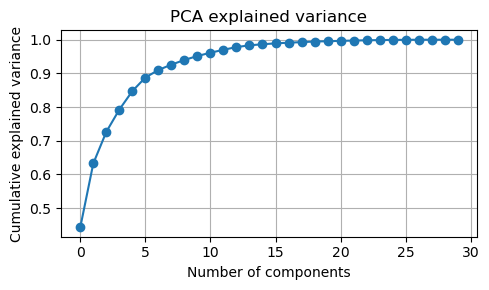

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
Z = pca.fit_transform(X_scaled)

plt.figure(figsize=(5,3))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.grid(True)
plt.tight_layout()
plt.show()

3 PCs explain 80% of the variance.


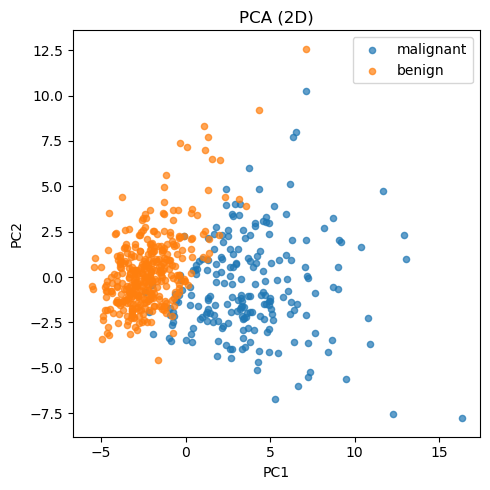

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(Z[y == 0, 0], Z[y == 0, 1], label="malignant", alpha=0.7, s=20)
plt.scatter(Z[y == 1, 0], Z[y == 1, 1], label="benign", alpha=0.7, s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D)")
plt.legend()
plt.tight_layout()
plt.show()

Clean clustering by target


In [ ]:
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=[f"PC{i+1}" for i in range(pca.n_components_)])

# Look at top contributors to PC1 and PC2
print(loadings[["PC1"]].sort_values("PC1", key=np.abs, ascending=False).head(10))
print(loadings[["PC2"]].sort_values("PC2", key=np.abs, ascending=False).head(10))

                           PC1
mean concave points   0.260854
mean concavity        0.258400
worst concave points  0.250886
mean compactness      0.239285
worst perimeter       0.236640
worst concavity       0.228768
worst radius          0.227997
mean perimeter        0.227537
worst area            0.224871
mean area             0.220995
                              PC2
mean fractal dimension   0.366575
fractal dimension error  0.280092
worst fractal dimension  0.275339
mean radius             -0.233857
compactness error        0.232716
mean area               -0.231077
worst radius            -0.219866
worst area              -0.219352
mean perimeter          -0.215181
smoothness error         0.204430


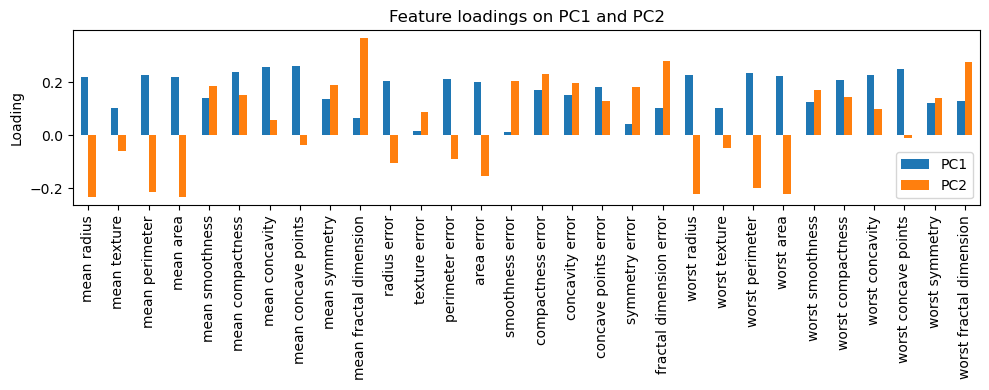

In [21]:

loadings[["PC1", "PC2"]].plot(kind="bar", figsize=(10,4))
plt.title("Feature loadings on PC1 and PC2")
plt.ylabel("Loading")
plt.tight_layout()
plt.show()
